<a href="https://colab.research.google.com/github/jefreeth/problema_parqueadero/blob/main/tamayo_jefree_ProbelmaParqueadero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#A

np.random.seed(123)
num_usuarios = 50
num_replicas = 50

tipos = np.random.choice(
    ["rapido", "normal", "lento", "muy lento"],
    size=num_usuarios,
    p = [0.25, 0.20, 0.30, 0.25]
)

df = pd.DataFrame({"tipo_usuario": tipos})


media_servicio = {"rapido": 1,
                  "normal": 3,
                  "lento": 4,
                  "muy lento": 6
  }

df["tiempo_servicio"] = df["tipo_usuario"].apply(
    lambda x: np.random.exponential(media_servicio[x])
)


df.groupby("tipo_usuario")["tiempo_servicio"].agg([
    "count",
    "mean",
    "min",
    "max"
])

df["cajero"] = np.random.choice(
    [1,2,3], size=num_usuarios
)

promedios_cajero = df.groupby("cajero")["tiempo_servicio"].mean()

print(promedios_cajero)

print("cajero con menor tiempo promedio: ", promedios_cajero.idxmin())

print("cajero con mayor tiempo proemedio: ", promedios_cajero.idxmax())


cajero
1    3.309061
2    2.790618
3    2.854497
Name: tiempo_servicio, dtype: float64
cajero con menor tiempo promedio:  2
cajero con mayor tiempo proemedio:  1


In [ ]:
df

,tipo_usuario,tiempo_servicio,cajero
0,lento,0.514192,2
1,normal,5.251982,2
2,rapido,0.923970,1
3,lento,3.150429,3
4,lento,1.678847,3
5,normal,1.087738,2
6,muy lento,3.237637,3
7,lento,4.574030,3
8,lento,8.332412,1
9,normal,2.142637,3


In [ ]:
np.random.seed(123)

promedios = []

for i in range(num_replicas):
  tipos = np.random.choice(
      ["rapido", "normal", "lento", "muy lento"],
      size=num_usuarios, p = [0.25, 0.20,0.30, 0.25]
  )

  tiempos = []

  for t in tipos:
    if t == "rapido":
      tiempos.append(np.random.exponential(1))
    elif t == "normal":
      tiempos.append(np.random.exponential(3))
    elif t == "lento":
      tiempos.append(np.random.exponential(4))
    else:
      tiempos.append(np.random.exponential(6))

  promedios.append(np.mean(tiempos))

media_acumulada = (pd.Series(promedios).expanding().mean())

print(np.mean(promedios))
print(media_acumulada)



3.4579491208390793
0     2.910767
1     3.156850
2     3.356209
3     3.317698
4     3.471772
5     3.414748
6     3.488989
7     3.482445
8     3.456990
9     3.364193
10    3.354757
11    3.302359
12    3.396615
13    3.427597
14    3.477096
15    3.502058
16    3.529160
17    3.524223
18    3.536705
19    3.506275
20    3.473179
21    3.498014
22    3.473481
23    3.453805
24    3.442099
25    3.429127
26    3.440445
27    3.448821
28    3.437735
29    3.452977
30    3.483344
31    3.464126
32    3.471850
33    3.492043
34    3.471308
35    3.454154
36    3.464049
37    3.447629
38    3.466045
39    3.451773
40    3.448377
41    3.478589
42    3.473440
43    3.450250
44    3.450501
45    3.455778
46    3.446280
47    3.450461
48    3.448888
49    3.457949
dtype: float64


In [ ]:
#B

promedio_usuarios = df['tipo_usuario'].value_counts()

print(promedio_usuarios)

tipo_usuario
lento        20
normal       17
rapido        7
muy lento     6
Name: count, dtype: int64


In [ ]:
#C
def simular_cajeros(num_cajeros):

    llegadas = np.cumsum(np.random.exponential(3, size=num_usuarios))

    cajeros_disponibles = [0] * num_cajeros

    esperas = []

    for i in range(num_usuarios):

        cajero = np.argmin(cajeros_disponibles)

        llegada = llegadas[i]
        servicio = df.loc[i, "tiempo_servicio"]

        inicio = max(llegada, cajeros_disponibles[cajero])

        fin = inicio + servicio

        espera = inicio - llegada

        cajeros_disponibles[cajero] = fin

        esperas.append(espera)

    return np.mean(esperas)


lista_esperas = simular_cajeros(3)

df["esperas"] = lista_esperas

espera_3 = simular_cajeros(3)
espera_4 = simular_cajeros(4)

print(f"3 cajeros -> {espera_3:.2f} min")
print(f"4 cajeros -> {espera_4:.2f} min")

if espera_3 < 5:
    print("Los 3 cajeros son suficientes.")
else:
    print("Se recomienda agregar otro cajero.")

3 cajeros -> 0.13 min
4 cajeros -> 0.00 min
Los 3 cajeros son suficientes.


In [ ]:
print(df["esperas"].describe())

count    50.000000
mean      0.033368
std       0.000000
min       0.033368
25%       0.033368
50%       0.033368
75%       0.033368
max       0.033368
Name: esperas, dtype: float64


In [ ]:
#D
print(df.head())
print(df["tipo_usuario"].value_counts())

  tipo_usuario  tiempo_servicio  cajero
0        lento         0.514192       2
1       normal         5.251982       2
2       rapido         0.923970       1
3        lento         3.150429       3
4        lento         1.678847       3
tipo_usuario
lento        20
normal       17
rapido        7
muy lento     6
Name: count, dtype: int64


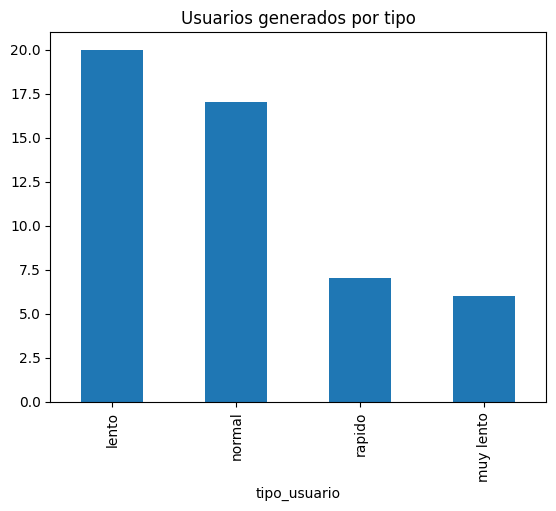

In [ ]:
df["tipo_usuario"].value_counts().plot(kind="bar")
plt.title("Usuarios generados por tipo")
plt.show()

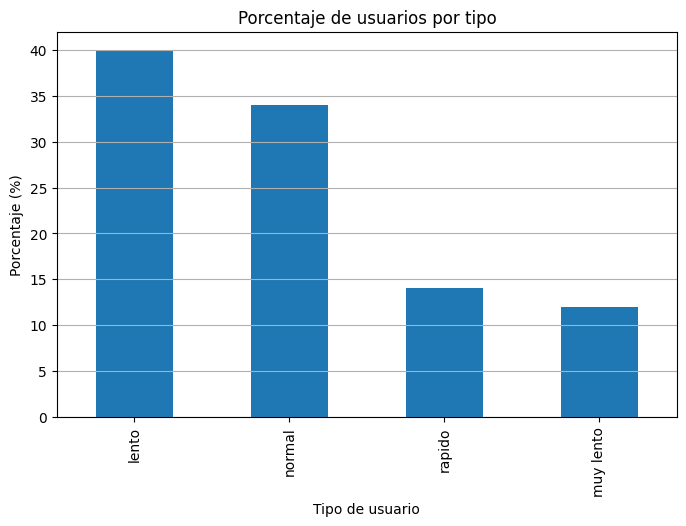

In [ ]:
porcentajes = (df["tipo_usuario"].value_counts(normalize=True)*100)

plt.figure(figsize=(8,5))

porcentajes.plot(kind="bar")

plt.title("Porcentaje de usuarios por tipo")
plt.xlabel("Tipo de usuario")
plt.ylabel("Porcentaje (%)")
plt.grid(axis="y")

plt.show()

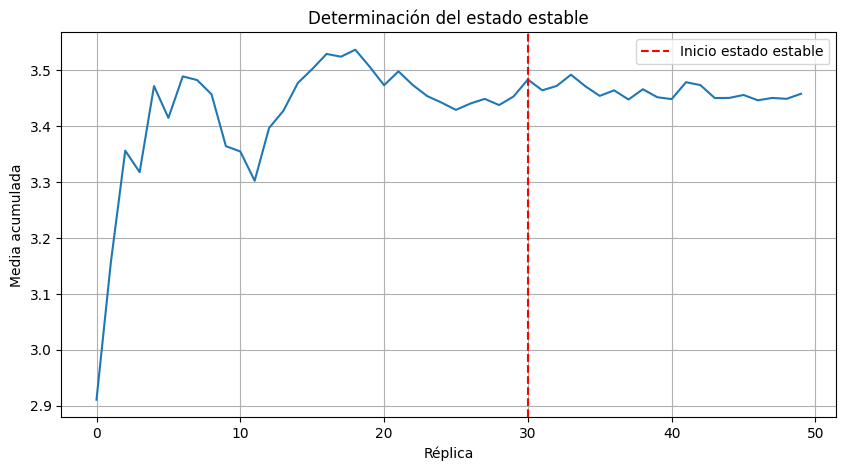

In [ ]:

plt.figure(figsize=(10,5))

plt.plot(media_acumulada)

plt.axvline(
    x=30,
    color="red",
    linestyle="--",
    label="Inicio estado estable"
)

plt.xlabel("Réplica")
plt.ylabel("Media acumulada")
plt.title("Determinación del estado estable")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#E
promedio_estable = promedios[30:]

print("media con transitorios", np.mean(promedios))

print("media sin trasitorios", np.mean(promedio_estable))


media con transitorios 3.4579491208390793
media sin trasitorios 3.4654080212330287


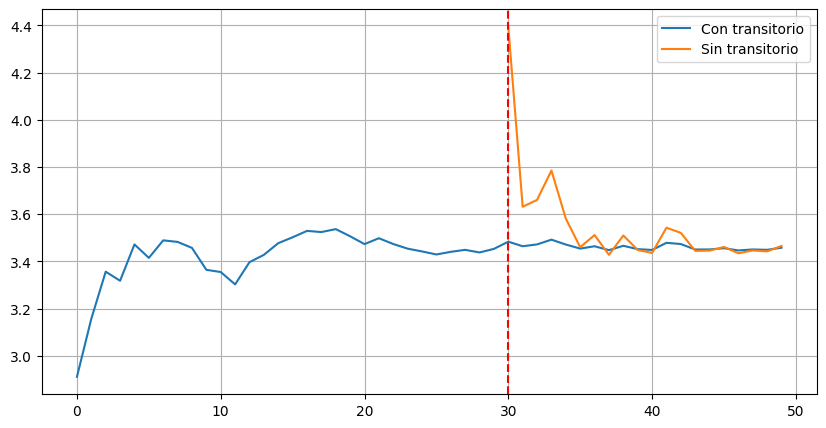

In [ ]:
media_original = pd.Series(promedios).expanding().mean()

media_estable = pd.Series(promedios[30:]).expanding().mean()

plt.figure(figsize=(10,5))

plt.plot(media_original,
         label="Con transitorio")

plt.plot(
    range(30, len(promedios)),
    media_estable,
    label="Sin transitorio"
)

plt.axvline(
    x=30,
    color="red",
    linestyle="--"
)

plt.legend()
plt.grid(True)
plt.show()